# Show scaled and translated wavelet on a signal

In [3]:
%load_ext autoreload
%autoreload 2

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../wavelet/')

import wavelet_funcs as wf

In [7]:
def cosine_signal(duration, frequency, sampling_frequency, amplitude=1.0, phase=0.0):
    """
    Generate a cosine signal.

    Parameters:
        duration (float): Signal duration in seconds
        frequency (float): Frequency of the cosine in Hz
        sampling_frequency (float): Sampling frequency in Hz
        amplitude (float): Amplitude of the cosine (default=1.0)
        phase (float): Phase shift in radians (default=0.0)

    Returns:
        t (numpy.ndarray): Time vector
        x (numpy.ndarray): Cosine signal
    """
    t = np.arange(0, duration, 1 / sampling_frequency)
    x = amplitude * np.cos(2 * np.pi * frequency * t + phase)
    return t, x

### Perfect cyclic cosine

In [10]:
t,s = cosine_signal(10, 2, 100)

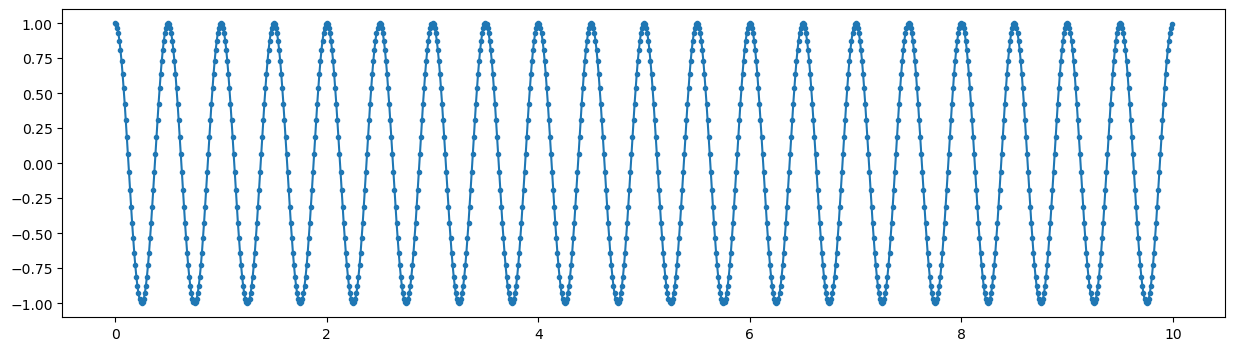

In [12]:
plt.figure(figsize=(15,4))
plt.plot(t, s, marker='.')

(<Figure size 1200x700 with 2 Axes>,
 (<Axes: ylabel='Contrast (dim. less)'>,
  <Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>))

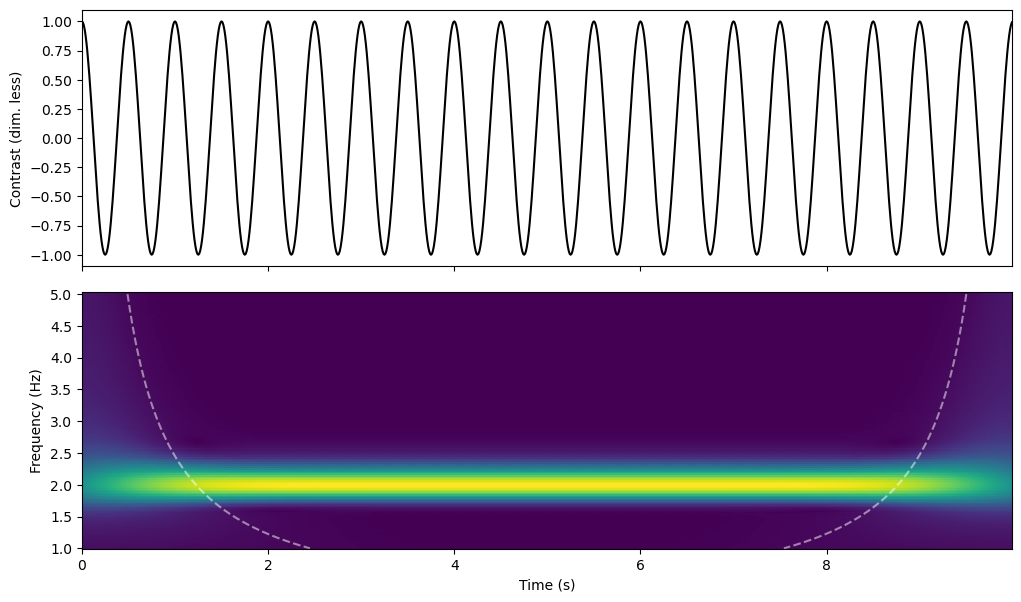

In [28]:
wf.plot_timeseries_and_its_cwt(s, t, f1=1, f2=5, method='fft', show_smoothed=False, central_freq=2, padding_fraction=0.)

# Show scaled and translated wavelet

In [79]:
scale = 0.5
shift = 0

B = 1.5
C = 1.0
wlt = f'cmor{B}-{C}'

In [81]:
wfun = wf.pywt.ContinuousWavelet(wlt)
psi, x = wfun.wavefun(level=15)

x_new = x*scale + shift
psi_new = psi.real/np.sqrt(scale)

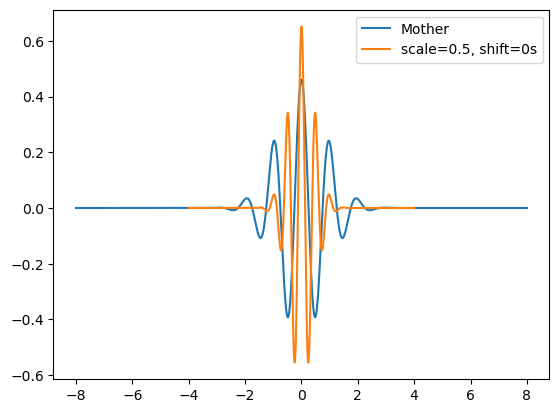

In [82]:
plt.plot(x, psi.real, label='Mother')
plt.plot(x_new, psi_new, label=f'scale={scale}, shift={shift}s')
plt.legend()

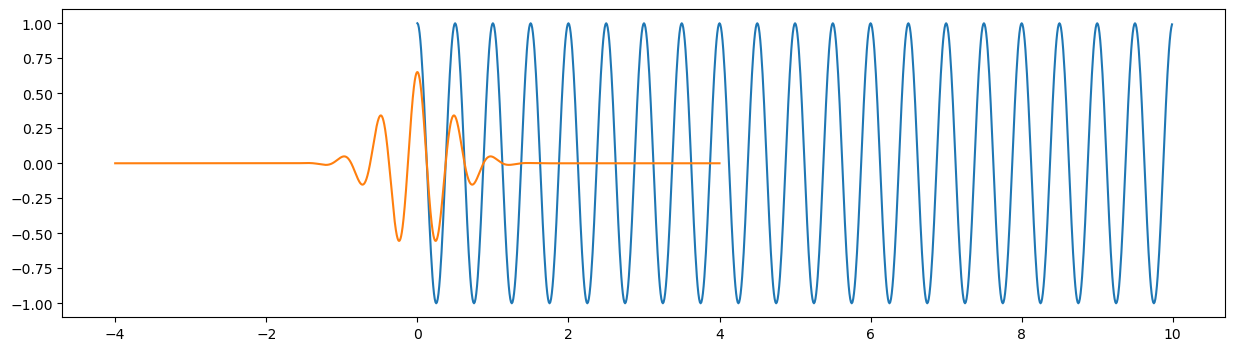

In [83]:
plt.figure(figsize=(15,4))
plt.plot(t,s)
plt.plot(x_new, psi_new)